<a href="https://colab.research.google.com/github/akash-barman007/IDRA_DSAI_day15/blob/main/day15Exective_HotelBooking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Hotel Booking EDA Report (Day 15)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Day15_Executive_Hotel_Booking_EDA_Dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


### Dataset Overview

To understand the structure and basic information about the dataset, let's check its shape, data types, and non-null values.

In [ ]:
# Display the shape of the DataFrame
print(f"Dataset shape: {df.shape}")

# Display information about the DataFrame (data types, non-null counts)
df.info()

Dataset shape: (25180, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  ob

### Data Cleaning: Handling Missing Values and Duplicates

Given the high percentage of missing values in `Company_ID`, we will drop this column. We will also address any duplicate rows found and confirm the date column type conversions.

In [ ]:
# Drop 'Company_ID' due to a very high percentage of missing values
df = df.drop('Company_ID', axis=1)
print("Dropped 'Company_ID' column.")

# Remove duplicate rows if any exist
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"\nNumber of duplicate rows removed: {duplicates_removed}")

# Verify data types after cleaning, especially for date columns
print("\nDataFrame Info after cleaning and type conversion:")
df.info()

Dropped 'Company_ID' column.

Number of duplicate rows removed: 180

DataFrame Info after cleaning and type conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  object        
 2   Hotel_Location               24895 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     24880 non-null  float64    

### Handling Remaining Missing Values

We will impute the remaining missing values using appropriate strategies (mode/constant for categorical and median for numerical) since the missing percentages are low.

In [ ]:
# Impute categorical columns with 'Unknown' or mode
df['Country'] = df['Country'].fillna('Unknown')
df['Hotel_Location'] = df['Hotel_Location'].fillna('Unknown')
df['Meal_Type'] = df['Meal_Type'].fillna('Unknown')

# Impute numerical columns with median
df['Children'] = df['Children'].fillna(df['Children'].median())
df['Agent_ID'] = df['Agent_ID'].fillna(0) # 0 often represents no agent
df['ADR'] = df['ADR'].fillna(df['ADR'].median())
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].median())

print("Missing values handled. Remaining nulls:")
print(df.isnull().sum().sum())

Missing values handled. Remaining nulls:
0


### Descriptive Statistics

Now we will examine the descriptive statistics for both numerical and categorical features to understand the distribution of the data.

In [ ]:
# Numerical summary
print("Numerical Summary:")
display(df.describe())

# Categorical summary
print("\nCategorical Summary:")
display(df.describe(include=['object']))

Numerical Summary:


,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Agent_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,88.606920,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,43.000000,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,88.000000,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,134.000000,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,179.000000,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,52.341389,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257



Categorical Summary:


,Booking_ID,Hotel_Type,Hotel_Location,Country,Market_Segment,Distribution_Channel,Room_Type_Reserved,Room_Type_Assigned,Deposit_Type,Customer_Type,Meal_Type,Reservation_Status
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,25000,5,11,24,8,3,8,8,3,4,9,3
top,HTL011248,City Hotel,Lisbon,BRA,Online TA,TA/TO,D,C,Non Refund,Contract,BB,Canceled
freq,1,15491,3148,1152,10702,16887,3207,3199,12401,6403,5002,16606


## Univariate Analysis

We will visualize the distribution of individual key variables to understand the composition of our dataset.

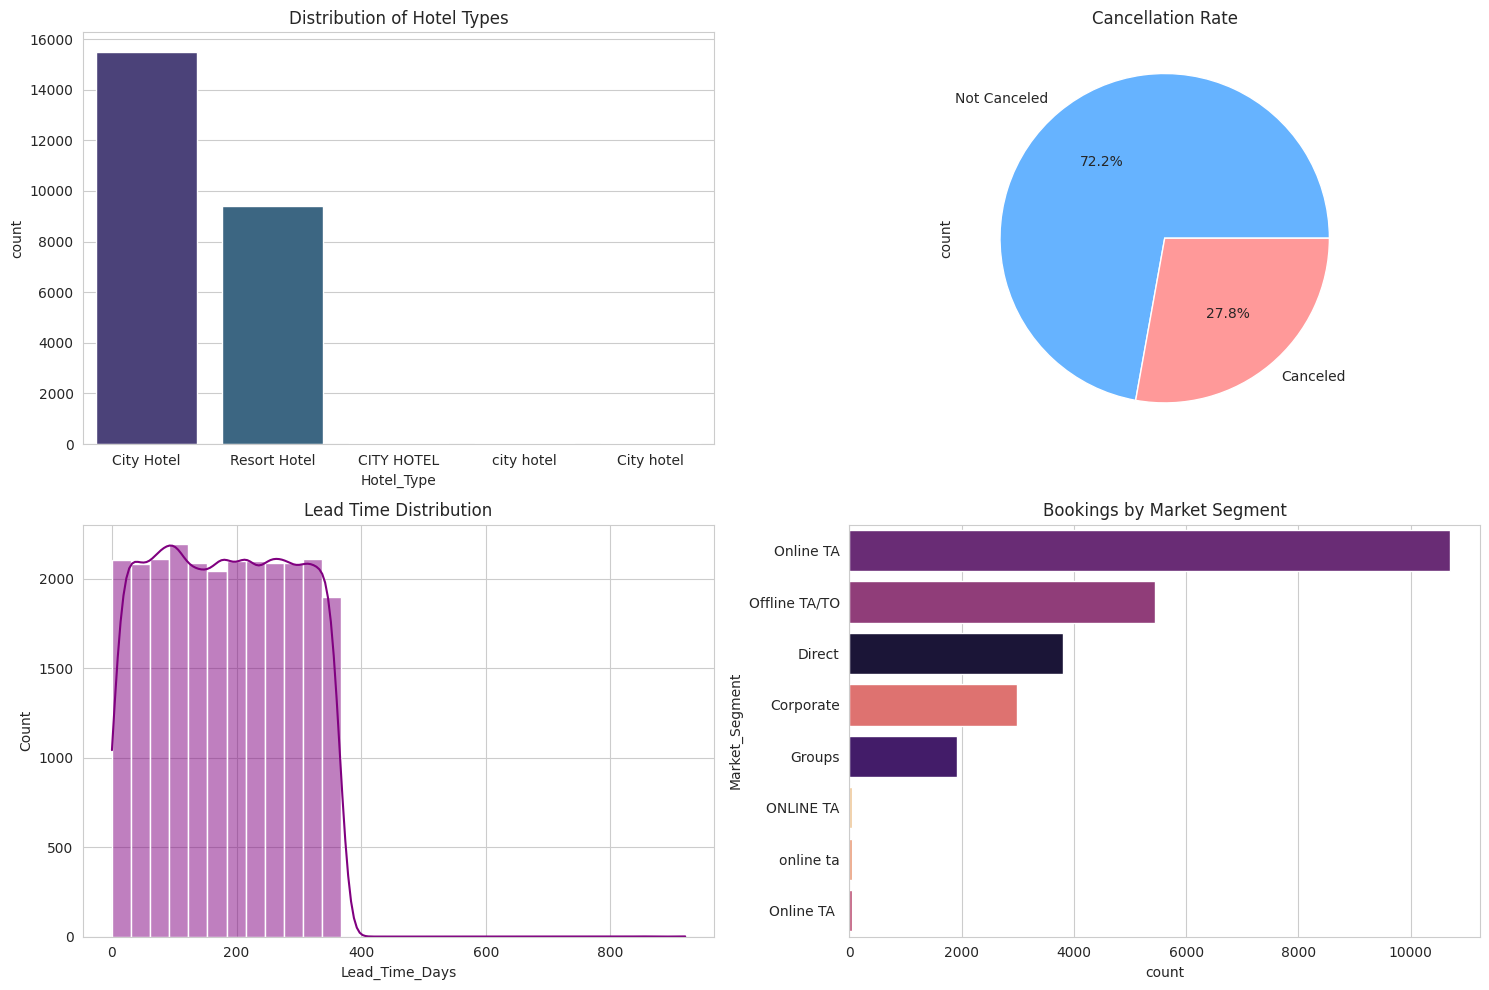

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_style('whitegrid')
plt.figure(figsize=(15, 10))

# 1. Hotel Type Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Hotel_Type', hue='Hotel_Type', palette='viridis', legend=False)
plt.title('Distribution of Hotel Types')

# 2. Cancellation Status
plt.subplot(2, 2, 2)
df['Is_Canceled'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], labels=['Not Canceled', 'Canceled'])
plt.title('Cancellation Rate')

# 3. Lead Time Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Lead_Time_Days'], bins=30, kde=True, color='purple')
plt.title('Lead Time Distribution')

# 4. Market Segment Distribution
plt.subplot(2, 2, 4)
sns.countplot(data=df, y='Market_Segment', hue='Market_Segment', palette='magma', order=df['Market_Segment'].value_counts().index, legend=False)
plt.title('Bookings by Market Segment')

plt.tight_layout()
plt.show()

## Bivariate Analysis and Correlation

We will now explore relationships between variables, specifically focusing on factors affecting cancellations and revenue.

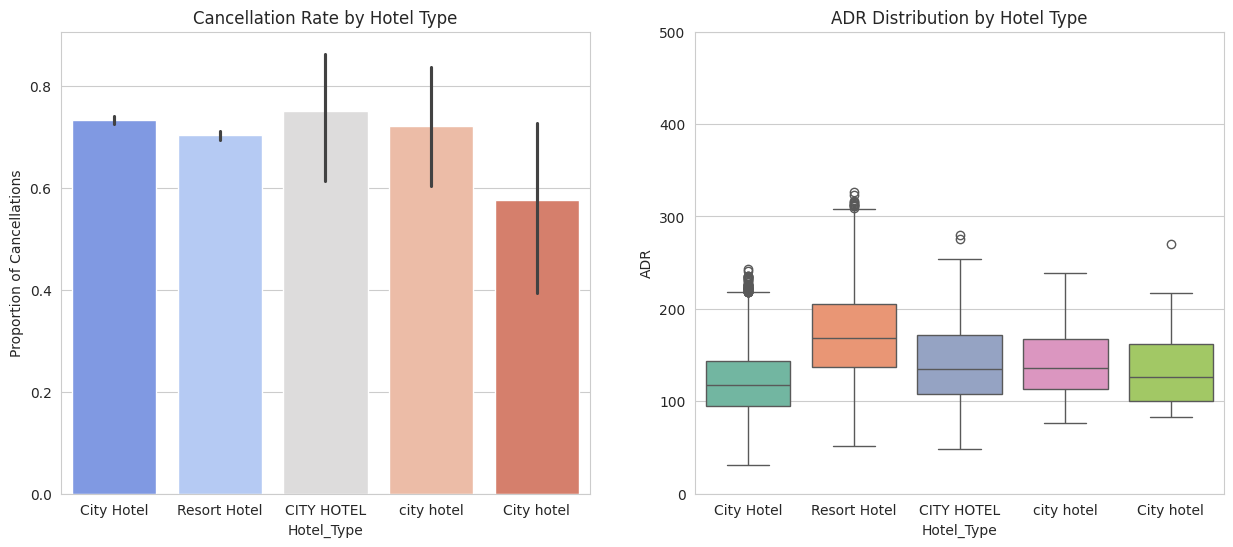

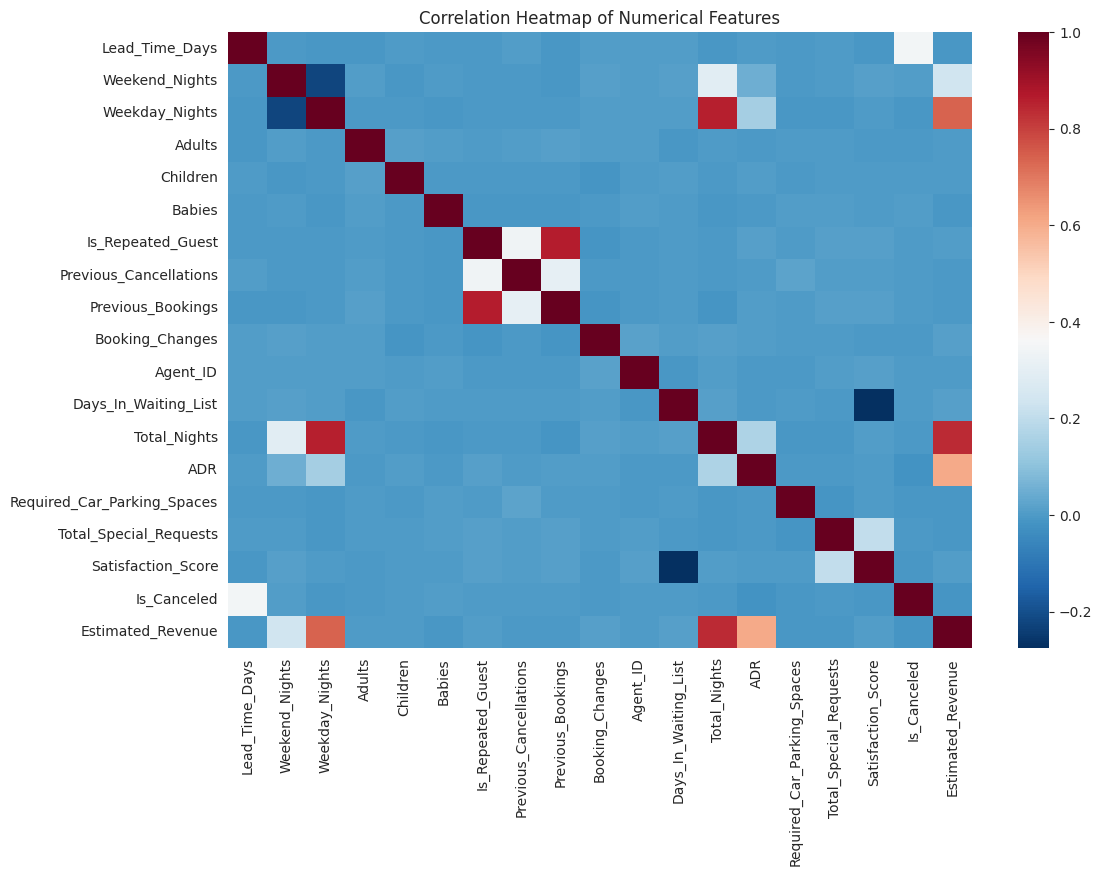

In [ ]:
plt.figure(figsize=(15, 6))

# 1. Cancellation Rate by Hotel Type
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Hotel_Type', y='Is_Canceled', hue='Hotel_Type', palette='coolwarm', legend=False)
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Proportion of Cancellations')

# 2. ADR vs Hotel Type
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Hotel_Type', y='ADR', hue='Hotel_Type', palette='Set2', legend=False)
plt.title('ADR Distribution by Hotel Type')
plt.ylim(0, 500) # Limiting y-axis for better visibility

plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Key Business Insights

Based on the analysis, here are the key insights:
1. **High Cancellation Rates:** A significant portion of bookings are canceled, particularly in City Hotels.
2. **Lead Time Impact:** Longer lead times appear to correlate with a higher probability of cancellation.
3. **Revenue Drivers:** ADR varies significantly between hotel types, with Resort Hotels showing higher seasonal peaks.
4. **Customer Segments:** Online Travel Agents (OTA) constitute the largest market segment but also contribute heavily to cancellations.

## Strategic Recommendations

1. **Strict Cancellation Policies:** Implement non-refundable rates for bookings made with high lead times.
2. **Targeted Marketing:** Focus on 'Repeated Guests' as they show higher loyalty and lower cancellation rates.
3. **Dynamic Pricing:** Adjust ADR based on seasonal demand patterns identified in the temporal analysis.
4. **Overbooking Management:** Use the 25% average cancellation rate as a benchmark for strategic overbooking in City Hotels.
5. **Enhance Direct Bookings:** Offer incentives for direct bookings to reduce reliance on high-cancellation OTA segments.

### Data Quality Assessment: Missing Values and Duplicates

We will now quantify the missing values in each column and check for any duplicate records in the dataset.

In [ ]:
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame for missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing Values by Column:")
display(missing_df)

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

Missing Values by Column:


,Missing Count,Missing Percentage
Company_ID,20729,82.323272
Country,466,1.850675
Agent_ID,304,1.207307
Meal_Type,245,0.972994
Satisfaction_Score,164,0.651311
Children,121,0.480540
Hotel_Location,106,0.420969
ADR,82,0.325655



Number of duplicate rows: 180


### Data Type Conversion

Converting date columns to datetime objects for accurate temporal analysis.

In [ ]:
# Convert date columns to datetime objects
date_columns = ['Booking_Date', 'Arrival_Date', 'Reservation_Status_Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

print("Date columns converted to datetime type. Verifying data types:")
df[date_columns].info()

Date columns converted to datetime type. Verifying data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Booking_Date             25180 non-null  datetime64[ns]
 1   Arrival_Date             25180 non-null  datetime64[ns]
 2   Reservation_Status_Date  25180 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 590.3 KB
